# **Fashion-MNIST Classifier: A Complete PyTorch Implementation**


---

## **Learning Objectives**

By the end of this tutorial, students will be able to:

1. **Implement** a complete image classification pipeline using PyTorch
2. **Build** and train a Multi-Layer Perceptron (MLP) for Fashion-MNIST classification
3. **Understand** the standard PyTorch workflow: data loading, model training, and evaluation
4. **Visualize** training progress, learned features, and model predictions
5. **Apply** best practices for deep learning model development
6. **Experiment** with different architectures and hyperparameters

---

## **Prerequisites**

- Understanding of basic neural network concepts (MLPs, backpropagation)
- Familiarity with Python programming and NumPy
- Basic knowledge of machine learning concepts (training, validation, testing)
- Introduction to PyTorch tensors and autograd (recommended)

## **1. Overview and Dataset Introduction**

### **1.1 Fashion-MNIST: Beyond Handwritten Digits**

**Fashion-MNIST** is a modern replacement for the classic MNIST dataset, created by Zalando Research. It maintains the same format as MNIST but provides more challenging, real-world image classification tasks.

**Why Fashion-MNIST?**
- **More realistic**: Real-world clothing items vs. artificial digits
- **Challenging**: Similar visual complexity between classes (e.g., shirt vs. dress)
- **Practical**: Directly applicable to e-commerce and fashion AI
- **Standard format**: Same dimensions as MNIST (28×28 grayscale images)

### **1.2 Dataset Specifications**

| **Property** | **Value** | **Description** |
|--------------|-----------|-----------------|
| **Training samples** | 60,000 | Images for model training |
| **Test samples** | 10,000 | Images for final evaluation |
| **Image dimensions** | 28×28×1 | Height × Width × Channels (grayscale) |
| **Classes** | 10 | Different clothing categories |
| **Pixel values** | 0-255 | Grayscale intensity values |

### **1.3 Class Labels and Categories**

| **Label** | **Class Name** | **Examples** |
|-----------|----------------|--------------|
| 0 | T-shirt/top | Basic t-shirts, tank tops |
| 1 | Trouser | Pants, jeans, trousers |
| 2 | Pullover | Sweaters, hoodies |
| 3 | Dress | Casual, formal dresses |
| 4 | Coat | Jackets, coats, blazers |
| 5 | Sandal | Open-toe footwear |
| 6 | Shirt | Button-up shirts, blouses |
| 7 | Sneaker | Athletic shoes, trainers |
| 8 | Bag | Handbags, backpacks |
| 9 | Ankle boot | Boots, high-top shoes |

### **1.4 Project Architecture Overview**

We'll implement a **Multi-Layer Perceptron (MLP)** with the following architecture:

```
Input Layer: 784 neurons (28×28 flattened pixels)
    ↓
Hidden Layer 1: 128 neurons + ReLU activation
    ↓
Hidden Layer 2: 64 neurons + ReLU activation
    ↓
Output Layer: 10 neurons (one per class) + Softmax
```

**Key Components:**
- **Data Loading**: Efficient batching with PyTorch DataLoader
- **Model Architecture**: Simple but effective MLP design
- **Training Loop**: Forward pass, loss computation, backpropagation
- **Evaluation**: Accuracy metrics and confusion matrix analysis
- **Visualization**: Training curves and prediction examples

In [1]:
# Essential imports for deep learning and visualization
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

# Data science and visualization libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Configure matplotlib for better visualization
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("   Running on CPU")

print(f"\n📦 Library Versions:")
print(f"   PyTorch: {torch.__version__}")
print(f"   NumPy: {np.__version__}")
print(f"   Matplotlib: {plt.matplotlib.__version__}")

print("\n✅ Environment setup complete!")

🚀 Using device: cpu
   Running on CPU

📦 Library Versions:
   PyTorch: 2.10.0+cpu
   NumPy: 2.4.1
   Matplotlib: 3.10.8

✅ Environment setup complete!


## **2. Data Loading and Exploration**

### **2.1 Data Preparation and Transforms**

PyTorch's `torchvision` provides convenient access to Fashion-MNIST. We'll apply essential preprocessing transforms to normalize the data for better training performance.

In [2]:
# Define data transforms for preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),                          # Convert PIL Image to tensor (0-255 → 0-1)
    transforms.Normalize((0.2860,), (0.3530,))     # Normalize with Fashion-MNIST statistics
])

# Fashion-MNIST class names for visualization
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print("📥 Loading Fashion-MNIST dataset...")

# Load training dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',           # Directory to store data
    train=True,              # Load training set
    download=True,           # Download if not already present
    transform=transform      # Apply preprocessing transforms
)

# Load test dataset
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,             # Load test set
    download=True,
    transform=transform
)

# Create data loaders for efficient batching
batch_size = 64  # Number of samples per batch (good balance of memory and gradient stability)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,            # Shuffle training data for better learning
    num_workers=2,           # Parallel data loading (adjust based on your system)
    pin_memory=True          # Speed up GPU transfer (if using GPU)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,           # No need to shuffle test data
    num_workers=2,
    pin_memory=True
)

print("✅ Dataset loading complete!")
print(f"\n📊 Dataset Statistics:")
print(f"   Training samples: {len(train_dataset):,}")
print(f"   Test samples: {len(test_dataset):,}")
print(f"   Number of classes: {len(class_names)}")
print(f"   Batch size: {batch_size}")
print(f"   Training batches: {len(train_loader):,}")
print(f"   Test batches: {len(test_loader):,}")

# Examine a single batch to understand data structure
sample_batch = next(iter(train_loader))
images, labels = sample_batch

print(f"\n🔍 Batch Analysis:")
print(f"   Images tensor shape: {images.shape}")  # [batch_size, channels, height, width]
print(f"   Labels tensor shape: {labels.shape}")  # [batch_size]
print(f"   Image data type: {images.dtype}")
print(f"   Label data type: {labels.dtype}")
print(f"   Image value range: [{images.min():.3f}, {images.max():.3f}]")

# Calculate input size for MLP (flattened image)
input_size = images[0].numel()  # Total number of pixels per image
print(f"   Input size for MLP: {input_size} (28×28 = {28*28})")

print(f"\n🎯 Class distribution in first batch:")
unique_labels, counts = torch.unique(labels, return_counts=True)
for label, count in zip(unique_labels, counts):
    print(f"   {class_names[label]}: {count.item()} samples")

📥 Loading Fashion-MNIST dataset...


100%|██████████| 26.4M/26.4M [00:03<00:00, 7.58MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 197kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.21MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.8MB/s]


✅ Dataset loading complete!

📊 Dataset Statistics:
   Training samples: 60,000
   Test samples: 10,000
   Number of classes: 10
   Batch size: 64
   Training batches: 938
   Test batches: 157

🔍 Batch Analysis:
   Images tensor shape: torch.Size([64, 1, 28, 28])
   Labels tensor shape: torch.Size([64])
   Image data type: torch.float32
   Label data type: torch.int64
   Image value range: [-0.810, 2.023]
   Input size for MLP: 784 (28×28 = 784)

🎯 Class distribution in first batch:
   T-shirt/top: 7 samples
   Trouser: 1 samples
   Pullover: 9 samples
   Dress: 11 samples
   Coat: 9 samples
   Sandal: 7 samples
   Shirt: 4 samples
   Sneaker: 5 samples
   Bag: 5 samples
   Ankle boot: 6 samples


### **2.2 Data Visualization and Analysis**

Let's explore the Fashion-MNIST dataset visually to understand what our model will be learning to classify.

🎨 Creating dataset visualization...


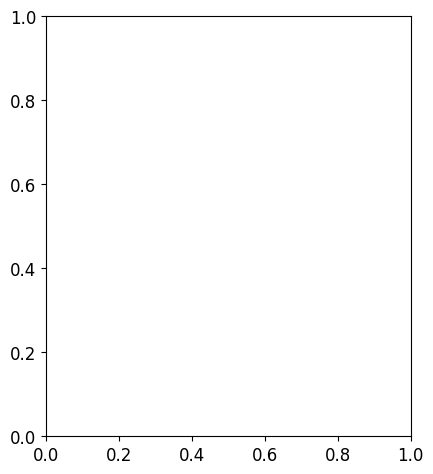

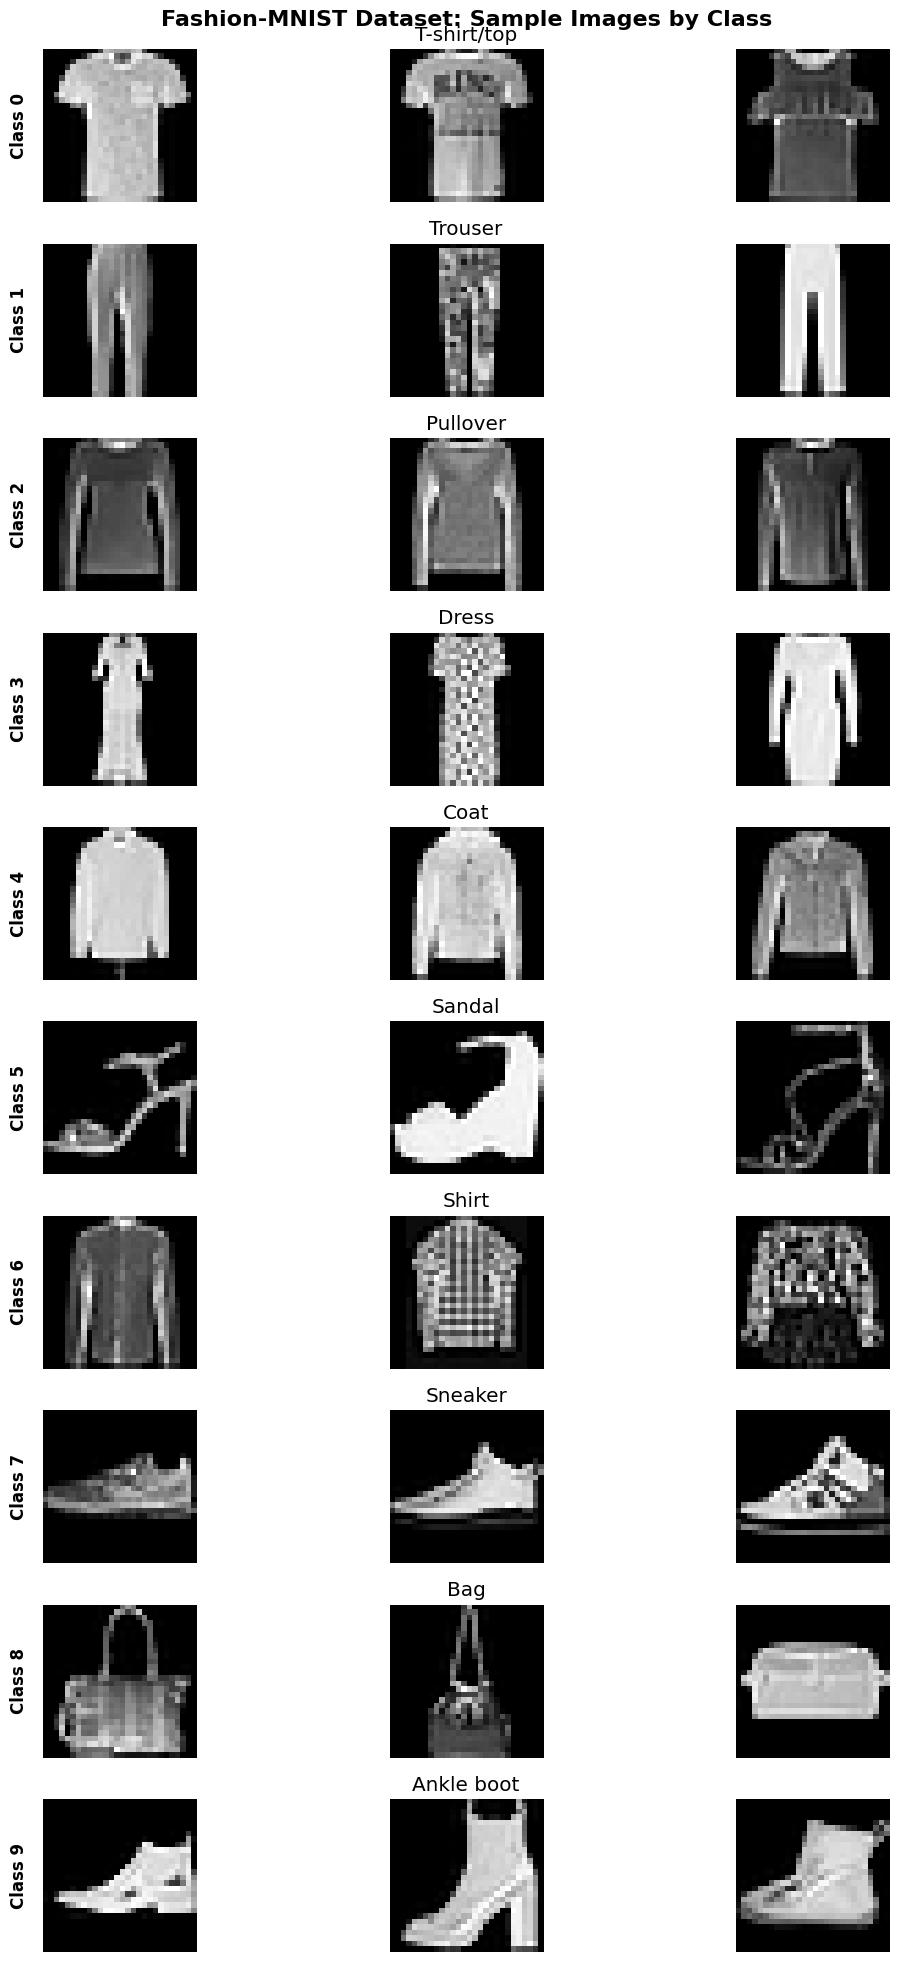

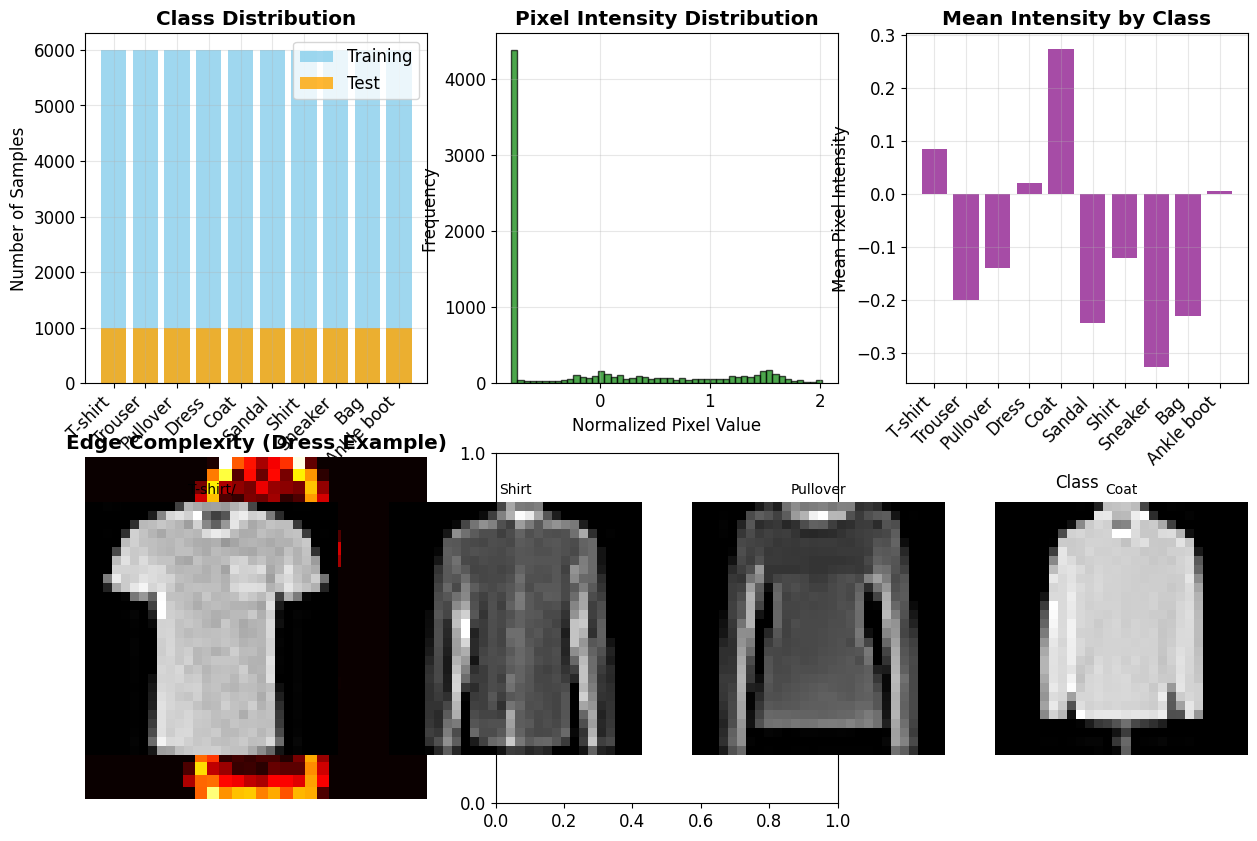

📊 Dataset Analysis Summary:
   • All classes are balanced with 6000 training samples each
   • Images are 28×28 grayscale (784 total pixels)
   • Pixel values normalized to ~[-2, +2] range after preprocessing
   • Visual complexity varies: bags/shoes (high detail) vs. simple clothing
   • Some classes share visual similarities (challenging for classification)

🧠 Key Challenges for Our MLP:
   • Distinguishing similar items (T-shirt vs. Shirt)
   • Handling intra-class variation (different dress styles)
   • Learning spatial relationships with flattened input
   • Generalizing across different orientations and styles


In [3]:
# Create comprehensive visualization of the Fashion-MNIST dataset
fig = plt.figure(figsize=(16, 12))

# Plot 1: Sample images from each class
print("🎨 Creating dataset visualization...")

# Get one example of each class
examples_per_class = 3
class_examples = {i: [] for i in range(10)}

# Collect examples for each class
for images, labels in train_loader:
    for i, label in enumerate(labels):
        class_idx = label.item()
        if len(class_examples[class_idx]) < examples_per_class:
            class_examples[class_idx].append(images[i])

    # Break if we have enough examples for all classes
    if all(len(examples) >= examples_per_class for examples in class_examples.values()):
        break

# Create subplot for class examples
plt.subplot(2, 3, 1)
fig_examples, axes = plt.subplots(10, examples_per_class, figsize=(12, 20))
fig_examples.suptitle('Fashion-MNIST Dataset: Sample Images by Class', fontsize=16, fontweight='bold')

for class_idx in range(10):
    for example_idx in range(examples_per_class):
        row, col = class_idx, example_idx
        image = class_examples[class_idx][example_idx].squeeze()  # Remove channel dimension

        axes[row, col].imshow(image, cmap='gray')
        axes[row, col].set_title(f'{class_names[class_idx]}' if col == 1 else '')
        axes[row, col].axis('off')

        # Add class label on the left
        if col == 0:
            axes[row, col].text(-0.1, 0.5, f'Class {class_idx}',
                               rotation=90, va='center', ha='right',
                               transform=axes[row, col].transAxes,
                               fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Plot 2: Class distribution analysis
plt.figure(figsize=(15, 10))

# Count samples per class in training set
train_class_counts = torch.zeros(10)
for _, labels in train_loader:
    for label in labels:
        train_class_counts[label.item()] += 1

# Count samples per class in test set
test_class_counts = torch.zeros(10)
for _, labels in test_loader:
    for label in labels:
        test_class_counts[label.item()] += 1

# Subplot 1: Class distribution
plt.subplot(2, 3, 1)
x_pos = np.arange(len(class_names))
plt.bar(x_pos, train_class_counts, alpha=0.8, color='skyblue', label='Training')
plt.bar(x_pos, test_class_counts, alpha=0.8, color='orange', label='Test')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Class Distribution', fontweight='bold')
plt.xticks(x_pos, [name.split('/')[0] for name in class_names], rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Pixel intensity distribution
plt.subplot(2, 3, 2)
sample_images = torch.cat([class_examples[i][0] for i in range(10)])
pixel_values = sample_images.flatten().numpy()
plt.hist(pixel_values, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Normalized Pixel Value')
plt.ylabel('Frequency')
plt.title('Pixel Intensity Distribution', fontweight='bold')
plt.grid(True, alpha=0.3)

# Subplot 3: Image statistics
plt.subplot(2, 3, 3)
mean_intensities = []
std_intensities = []
for i in range(10):
    class_images = torch.stack(class_examples[i])
    mean_intensities.append(class_images.mean().item())
    std_intensities.append(class_images.std().item())

plt.bar(range(10), mean_intensities, alpha=0.7, color='purple')
plt.xlabel('Class')
plt.ylabel('Mean Pixel Intensity')
plt.title('Mean Intensity by Class', fontweight='bold')
plt.xticks(range(10), [name.split('/')[0] for name in class_names], rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# Subplot 4: Sample complexity visualization
plt.subplot(2, 3, 4)
# Show edge detection on sample images to illustrate complexity
sample_image = class_examples[3][0].squeeze().numpy()  # Dress example
edges = np.abs(np.gradient(sample_image)[0]) + np.abs(np.gradient(sample_image)[1])
plt.imshow(edges, cmap='hot')
plt.title('Edge Complexity (Dress Example)', fontweight='bold')
plt.axis('off')

# Subplot 5: Correlation between similar classes
plt.subplot(2, 3, 5)
# Create confusion preview by showing visually similar classes
similar_pairs = [(0, 6), (2, 4), (5, 9), (7, 9)]  # T-shirt/Shirt, Pullover/Coat, etc.
comparison_images = []
comparison_labels = []

for class1, class2 in similar_pairs:
    comparison_images.extend([class_examples[class1][0], class_examples[class2][0]])
    comparison_labels.extend([f'{class_names[class1][:8]}', f'{class_names[class2][:8]}'])

# Show side-by-side comparison
for i, (img, label) in enumerate(zip(comparison_images[:4], comparison_labels[:4])):
    plt.subplot(2, 4, i+5)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(label, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

print("📊 Dataset Analysis Summary:")
print(f"   • All classes are balanced with {train_class_counts[0].int()} training samples each")
print(f"   • Images are 28×28 grayscale (784 total pixels)")
print(f"   • Pixel values normalized to ~[-2, +2] range after preprocessing")
print(f"   • Visual complexity varies: bags/shoes (high detail) vs. simple clothing")
print(f"   • Some classes share visual similarities (challenging for classification)")

print(f"\n🧠 Key Challenges for Our MLP:")
print(f"   • Distinguishing similar items (T-shirt vs. Shirt)")
print(f"   • Handling intra-class variation (different dress styles)")
print(f"   • Learning spatial relationships with flattened input")
print(f"   • Generalizing across different orientations and styles")

## **3. Model Architecture: Multi-Layer Perceptron (MLP)**

### **3.1 Architecture Design Principles**

Our **Multi-Layer Perceptron (MLP)** follows proven design principles for image classification:

**Architecture Flow:**
1. **Input Layer**: 784 neurons (28×28 flattened pixels)
2. **Hidden Layer 1**: 128 neurons with ReLU activation
3. **Hidden Layer 2**: 64 neurons with ReLU activation  
4. **Output Layer**: 10 neurons with Softmax activation (class probabilities)

**Design Rationale:**
- **Flattening**: Convert 2D images to 1D vectors for MLP processing
- **Hidden layers**: Learn increasingly abstract feature representations
- **ReLU activation**: Prevents vanishing gradients, enables non-linearity
- **Decreasing neurons**: Funnel information from detailed to abstract
- **Softmax output**: Convert logits to probability distribution over classes

🧠 Creating Fashion-MNIST MLP model...

📋 Model Architecture:
FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden1): Linear(in_features=784, out_features=128, bias=True)
  (hidden2): Linear(in_features=128, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)

📊 Model Statistics:
   Architecture: 784 → 128 → 64 → 10
   Total Parameters: 109,386
   Trainable Parameters: 109,386
   Model Size (MB): 0.42


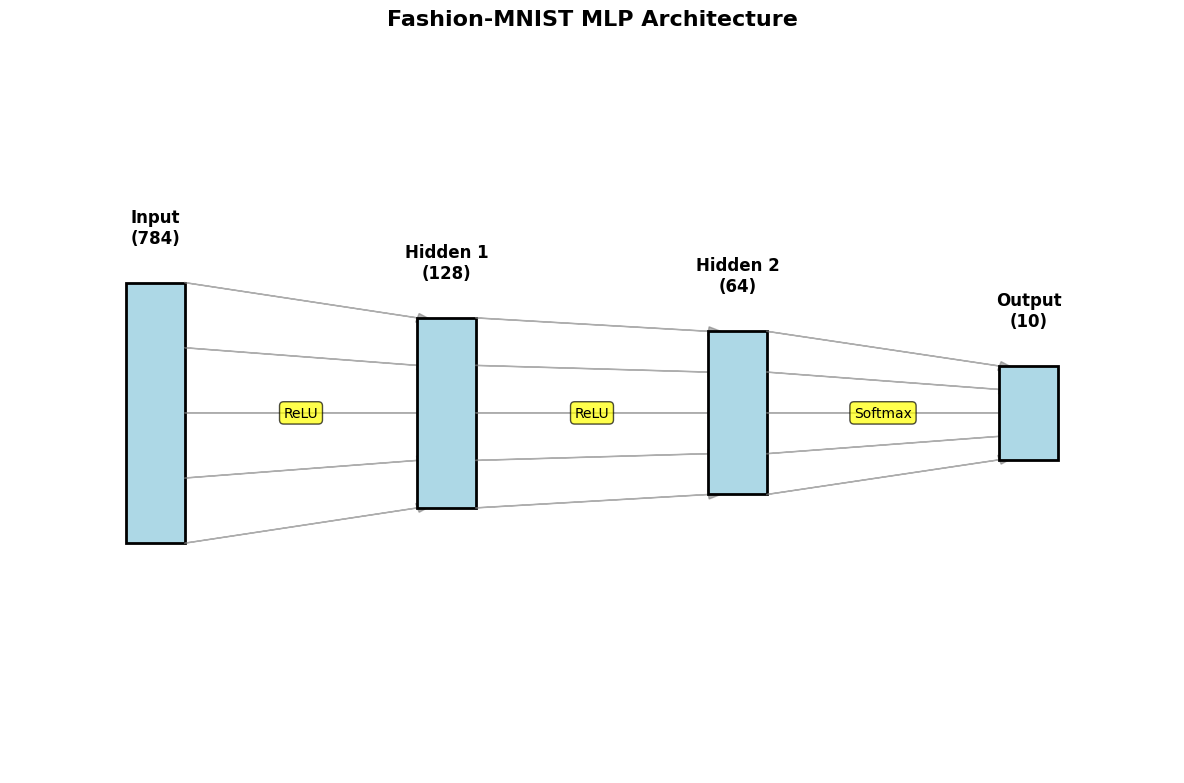


🔍 Testing forward pass:
   Input shape: torch.Size([32, 1, 28, 28])
   Output shape: torch.Size([32, 10])
   Output range: [-0.336, 0.383]
   Probability range: [0.072, 0.143]
   Probability sum per sample: 1.000 (should be ~1.0)

✅ Model created and tested successfully!


In [4]:
class FashionMLP(nn.Module):
    """
    Multi-Layer Perceptron for Fashion-MNIST Classification

    Architecture: 784 → 128 → 64 → 10
    - Input: Flattened 28×28 images (784 features)
    - Hidden layers: ReLU activation for non-linearity
    - Output: 10 class probabilities (softmax applied in loss function)
    """

    def __init__(self, input_size=784, hidden1_size=128, hidden2_size=64, num_classes=10):
        super(FashionMLP, self).__init__()

        # Define network layers
        self.flatten = nn.Flatten()                    # Convert 2D images to 1D vectors

        self.hidden1 = nn.Linear(input_size, hidden1_size)     # First hidden layer
        self.hidden2 = nn.Linear(hidden1_size, hidden2_size)   # Second hidden layer
        self.output = nn.Linear(hidden2_size, num_classes)     # Output layer

        # Activation function (applied between layers)
        self.relu = nn.ReLU()

        # Dropout for regularization (optional, can be enabled during training)
        self.dropout = nn.Dropout(p=0.2)

        # Store architecture info
        self.input_size = input_size
        self.hidden1_size = hidden1_size
        self.hidden2_size = hidden2_size
        self.num_classes = num_classes

    def forward(self, x):
        """
        Forward pass through the network

        Args:
            x: Input tensor of shape (batch_size, 1, 28, 28)

        Returns:
            logits: Output tensor of shape (batch_size, num_classes)
        """
        # Flatten the input images: (batch_size, 1, 28, 28) → (batch_size, 784)
        x = self.flatten(x)

        # First hidden layer: 784 → 128
        x = self.hidden1(x)      # Linear transformation
        x = self.relu(x)         # ReLU activation
        x = self.dropout(x)      # Dropout for regularization

        # Second hidden layer: 128 → 64
        x = self.hidden2(x)      # Linear transformation
        x = self.relu(x)         # ReLU activation
        x = self.dropout(x)      # Dropout for regularization

        # Output layer: 64 → 10 (no activation, will be applied in loss function)
        logits = self.output(x)

        return logits

    def get_model_info(self):
        """Get detailed information about the model architecture"""
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)

        info = {
            'Architecture': f'{self.input_size} → {self.hidden1_size} → {self.hidden2_size} → {self.num_classes}',
            'Total Parameters': f'{total_params:,}',
            'Trainable Parameters': f'{trainable_params:,}',
            'Model Size (MB)': f'{total_params * 4 / (1024**2):.2f}',  # Assuming float32
        }
        return info

# Initialize the model and move to device
print("🧠 Creating Fashion-MNIST MLP model...")
model = FashionMLP().to(device)

# Display model architecture
print("\n📋 Model Architecture:")
print(model)

# Get detailed model information
model_info = model.get_model_info()
print(f"\n📊 Model Statistics:")
for key, value in model_info.items():
    print(f"   {key}: {value}")

# Visualize model architecture
def visualize_model_architecture():
    """Create a visual representation of the MLP architecture"""
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    # Define layer positions
    layers = ['Input\n(784)', 'Hidden 1\n(128)', 'Hidden 2\n(64)', 'Output\n(10)']
    layer_sizes = [784, 128, 64, 10]
    positions = [0, 1, 2, 3]

    # Plot layers as rectangles
    for i, (pos, size, label) in enumerate(zip(positions, layer_sizes, layers)):
        # Rectangle height proportional to layer size (with scaling for visibility)
        height = np.log10(size + 1) * 0.5
        rect = plt.Rectangle((pos-0.1, -height/2), 0.2, height,
                           facecolor='lightblue', edgecolor='black', linewidth=2)
        ax.add_patch(rect)

        # Add layer labels
        ax.text(pos, height/2 + 0.2, label, ha='center', va='bottom',
                fontweight='bold', fontsize=12)

        # Add activation function labels
        if i < len(layers) - 1:  # Not for output layer
            activation = 'ReLU' if i < len(layers) - 2 else 'Softmax'
            ax.text(pos + 0.5, 0, activation, ha='center', va='center',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7),
                   fontsize=10)

        # Draw connections to next layer
        if i < len(layers) - 1:
            # Draw multiple arrows to represent connections
            for j in range(5):  # Just show a few representative connections
                y_start = height/2 - (j * height/4)
                y_end = np.log10(layer_sizes[i+1] + 1) * 0.25 - (j * np.log10(layer_sizes[i+1] + 1) * 0.125)
                ax.arrow(pos + 0.1, y_start, 0.8, y_end - y_start,
                        head_width=0.05, head_length=0.05, fc='gray', ec='gray', alpha=0.6)

    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-2, 2)
    ax.set_title('Fashion-MNIST MLP Architecture', fontsize=16, fontweight='bold', pad=20)
    ax.axis('off')

    plt.tight_layout()
    plt.show()

visualize_model_architecture()

# Test forward pass with a sample batch
print(f"\n🔍 Testing forward pass:")
with torch.no_grad():
    sample_input = torch.randn(32, 1, 28, 28).to(device)  # Batch of 32 random images
    output = model(sample_input)
    print(f"   Input shape: {sample_input.shape}")
    print(f"   Output shape: {output.shape}")
    print(f"   Output range: [{output.min():.3f}, {output.max():.3f}]")

    # Apply softmax to see probabilities
    probabilities = F.softmax(output, dim=1)
    print(f"   Probability range: [{probabilities.min():.3f}, {probabilities.max():.3f}]")
    print(f"   Probability sum per sample: {probabilities.sum(dim=1)[0]:.3f} (should be ~1.0)")

print("\n✅ Model created and tested successfully!")

## **4. Training Configuration and Setup**

### **4.1 Loss Function and Optimizer Selection**

**Loss Function: Cross-Entropy Loss**
- Perfect for multi-class classification
- Combines softmax activation with negative log-likelihood
- Penalizes confident wrong predictions more heavily

**Optimizer: Adam**
- Adaptive learning rate for each parameter
- Combines benefits of momentum and RMSprop
- Generally converges faster than SGD for neural networks

In [6]:
# Training configuration
learning_rate = 0.001      # Adam's default learning rate (works well for most cases)
num_epochs = 10            # Number of complete passes through the dataset
weight_decay = 1e-4        # L2 regularization to prevent overfitting

# Initialize loss function and optimizer
criterion = nn.CrossEntropyLoss()                           # Multi-class classification loss
optimizer = optim.Adam(model.parameters(),                  # Adam optimizer
                      lr=learning_rate,                     # Learning rate
                      weight_decay=weight_decay)            # L2 regularization

print("⚙️ Training Configuration:")
print(f"   Learning Rate: {learning_rate}")
print(f"   Number of Epochs: {num_epochs}")
print(f"   Optimizer: Adam with weight decay {weight_decay}")
print(f"   Loss Function: Cross-Entropy Loss")
print(f"   Batch Size: {batch_size}")

def calculate_accuracy(outputs, labels):
    """
    Calculate classification accuracy

    Args:
        outputs: Model predictions (logits)
        labels: True class labels

    Returns:
        accuracy: Percentage of correct predictions
    """
    _, predicted = torch.max(outputs.data, 1)
    total = labels.size(0)
    correct = (predicted == labels).sum().item()
    return 100 * correct / total

def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train the model for one epoch

    Args:
        model: Neural network model
        dataloader: Training data loader
        criterion: Loss function
        optimizer: Optimization algorithm
        device: Computing device (CPU/GPU)

    Returns:
        avg_loss: Average loss for the epoch
        avg_accuracy: Average accuracy for the epoch
    """
    model.train()  # Set model to training mode (enables dropout, batch norm, etc.)

    total_loss = 0.0
    total_accuracy = 0.0
    num_batches = 0

    for batch_idx, (images, labels) in enumerate(dataloader):
        # Move data to device
        images, labels = images.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Calculate metrics
        accuracy = calculate_accuracy(outputs, labels)
        total_loss += loss.item()
        total_accuracy += accuracy
        num_batches += 1

        # Print progress every 200 batches
        if (batch_idx + 1) % 200 == 0:
            print(f'   Batch [{batch_idx+1}/{len(dataloader)}] - '
                  f'Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%')

    avg_loss = total_loss / num_batches
    avg_accuracy = total_accuracy / num_batches

    return avg_loss, avg_accuracy

def evaluate_model(model, dataloader, criterion, device):
    """
    Evaluate the model on a dataset

    Args:
        model: Neural network model
        dataloader: Evaluation data loader
        criterion: Loss function
        device: Computing device (CPU/GPU)

    Returns:
        avg_loss: Average loss
        avg_accuracy: Average accuracy
        all_predictions: All model predictions
        all_labels: All true labels
    """
    model.eval()  # Set model to evaluation mode (disables dropout, etc.)

    total_loss = 0.0
    total_accuracy = 0.0
    num_batches = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():  # Disable gradient computation for efficiency
        for images, labels in dataloader:
            # Move data to device
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Calculate metrics
            accuracy = calculate_accuracy(outputs, labels)
            total_loss += loss.item()
            total_accuracy += accuracy
            num_batches += 1

            # Store predictions and labels for detailed analysis
            _, predicted = torch.max(outputs.data, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / num_batches
    avg_accuracy = total_accuracy / num_batches

    return avg_loss, avg_accuracy, all_predictions, all_labels

# Prepare for training tracking
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

print(f"\n🚀 Training setup complete! Ready to train for {num_epochs} epochs.")
print(f"📊 Training data: {len(train_dataset):,} samples in {len(train_loader)} batches")
print(f"📊 Test data: {len(test_dataset):,} samples in {len(test_loader)} batches")

⚙️ Training Configuration:
   Learning Rate: 0.001
   Number of Epochs: 10
   Optimizer: Adam with weight decay 0.0001
   Loss Function: Cross-Entropy Loss
   Batch Size: 64

🚀 Training setup complete! Ready to train for 10 epochs.
📊 Training data: 60,000 samples in 938 batches
📊 Test data: 10,000 samples in 157 batches


### **4.2 Main Training Loop**

Now let's train our model and monitor its progress on both training and test sets!

🏋️ Starting training...

Epoch [1/10]
--------------------------------------------------
🔄 Training...
   Batch [200/938] - Loss: 0.3639, Accuracy: 85.94%
   Batch [400/938] - Loss: 0.5083, Accuracy: 82.81%
   Batch [600/938] - Loss: 0.7174, Accuracy: 76.56%
   Batch [800/938] - Loss: 0.4527, Accuracy: 82.81%
📊 Evaluating...

📈 Epoch 1 Summary:
   Train Loss: 0.5482 | Train Accuracy: 80.41%
   Test Loss:  0.4148 | Test Accuracy:  84.56%
   Time: 15.49s

Epoch [2/10]
--------------------------------------------------
🔄 Training...
   Batch [200/938] - Loss: 0.5104, Accuracy: 81.25%
   Batch [400/938] - Loss: 0.3954, Accuracy: 82.81%
   Batch [600/938] - Loss: 0.6732, Accuracy: 82.81%
   Batch [800/938] - Loss: 0.2845, Accuracy: 92.19%
📊 Evaluating...

📈 Epoch 2 Summary:
   Train Loss: 0.4088 | Train Accuracy: 85.31%
   Test Loss:  0.3894 | Test Accuracy:  85.99%
   Time: 13.87s

Epoch [3/10]
--------------------------------------------------
🔄 Training...
   Batch [200/938] - Loss: 0.31

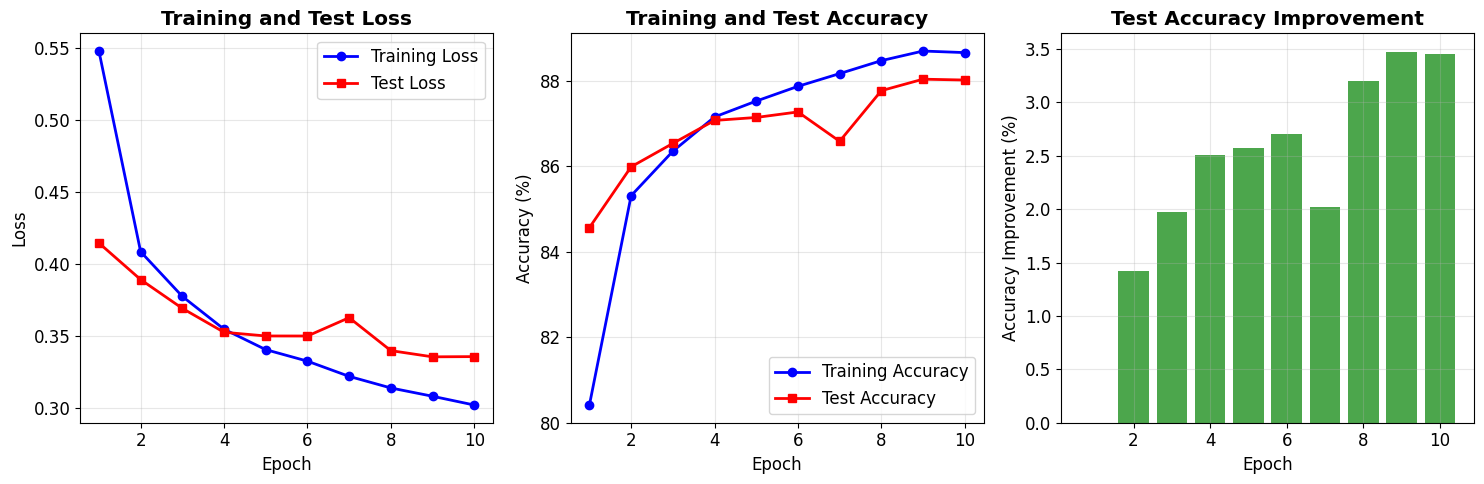


📊 Training Statistics:
   Best test accuracy: 88.04% (Epoch 9)
   Final train accuracy: 88.66%
   Final test accuracy: 88.02%
   Overfitting gap: 0.64%
   ✅ Good generalization (minimal overfitting)

🎉 Model successfully trained! Ready for detailed evaluation.


In [7]:
# Main training loop
print("🏋️ Starting training...")
print("=" * 80)

import time
start_time = time.time()

for epoch in range(num_epochs):
    epoch_start_time = time.time()

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print("-" * 50)

    # Training phase
    print("🔄 Training...")
    train_loss, train_accuracy = train_epoch(model, train_loader, criterion, optimizer, device)

    # Evaluation phase
    print("📊 Evaluating...")
    test_loss, test_accuracy, _, _ = evaluate_model(model, test_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    # Calculate epoch time
    epoch_time = time.time() - epoch_start_time

    # Print epoch summary
    print(f"\n📈 Epoch {epoch+1} Summary:")
    print(f"   Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%")
    print(f"   Test Loss:  {test_loss:.4f} | Test Accuracy:  {test_accuracy:.2f}%")
    print(f"   Time: {epoch_time:.2f}s")

    # Early stopping check (optional)
    if test_accuracy > 97.0:
        print(f"🎯 Target accuracy reached! Stopping early.")
        break

total_time = time.time() - start_time
print("\n" + "=" * 80)
print("✅ Training completed!")
print(f"🕒 Total training time: {total_time:.2f}s ({total_time/60:.1f} minutes)")
print(f"🎯 Final test accuracy: {test_accuracies[-1]:.2f}%")

# Create real-time training visualization
plt.figure(figsize=(15, 5))

# Plot 1: Loss curves
plt.subplot(1, 3, 1)
epochs_range = range(1, len(train_losses) + 1)
plt.plot(epochs_range, train_losses, 'b-o', label='Training Loss', linewidth=2, markersize=6)
plt.plot(epochs_range, test_losses, 'r-s', label='Test Loss', linewidth=2, markersize=6)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Accuracy curves
plt.subplot(1, 3, 2)
plt.plot(epochs_range, train_accuracies, 'b-o', label='Training Accuracy', linewidth=2, markersize=6)
plt.plot(epochs_range, test_accuracies, 'r-s', label='Test Accuracy', linewidth=2, markersize=6)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Test Accuracy', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Learning progress summary
plt.subplot(1, 3, 3)
improvement = np.array(test_accuracies) - test_accuracies[0]
plt.bar(epochs_range, improvement, alpha=0.7, color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Improvement (%)')
plt.title('Test Accuracy Improvement', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Training statistics summary
print(f"\n📊 Training Statistics:")
print(f"   Best test accuracy: {max(test_accuracies):.2f}% (Epoch {test_accuracies.index(max(test_accuracies))+1})")
print(f"   Final train accuracy: {train_accuracies[-1]:.2f}%")
print(f"   Final test accuracy: {test_accuracies[-1]:.2f}%")
print(f"   Overfitting gap: {train_accuracies[-1] - test_accuracies[-1]:.2f}%")

if train_accuracies[-1] - test_accuracies[-1] > 10:
    print("   ⚠️  Significant overfitting detected!")
elif train_accuracies[-1] - test_accuracies[-1] > 5:
    print("   ⚠️  Mild overfitting detected")
else:
    print("   ✅ Good generalization (minimal overfitting)")

print(f"\n🎉 Model successfully trained! Ready for detailed evaluation.")

## **5. Model Evaluation and Analysis**

### **5.1 Comprehensive Performance Analysis**

Let's perform a detailed evaluation of our trained model, including confusion matrix analysis, per-class performance, and error analysis.

🔍 Performing comprehensive evaluation...
📊 Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.81      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.78      0.83      0.80      1000
       Dress       0.84      0.92      0.88      1000
        Coat       0.82      0.76      0.79      1000
      Sandal       0.98      0.94      0.96      1000
       Shirt       0.70      0.69      0.70      1000
     Sneaker       0.91      0.97      0.94      1000
         Bag       0.96      0.97      0.96      1000
  Ankle boot       0.96      0.94      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



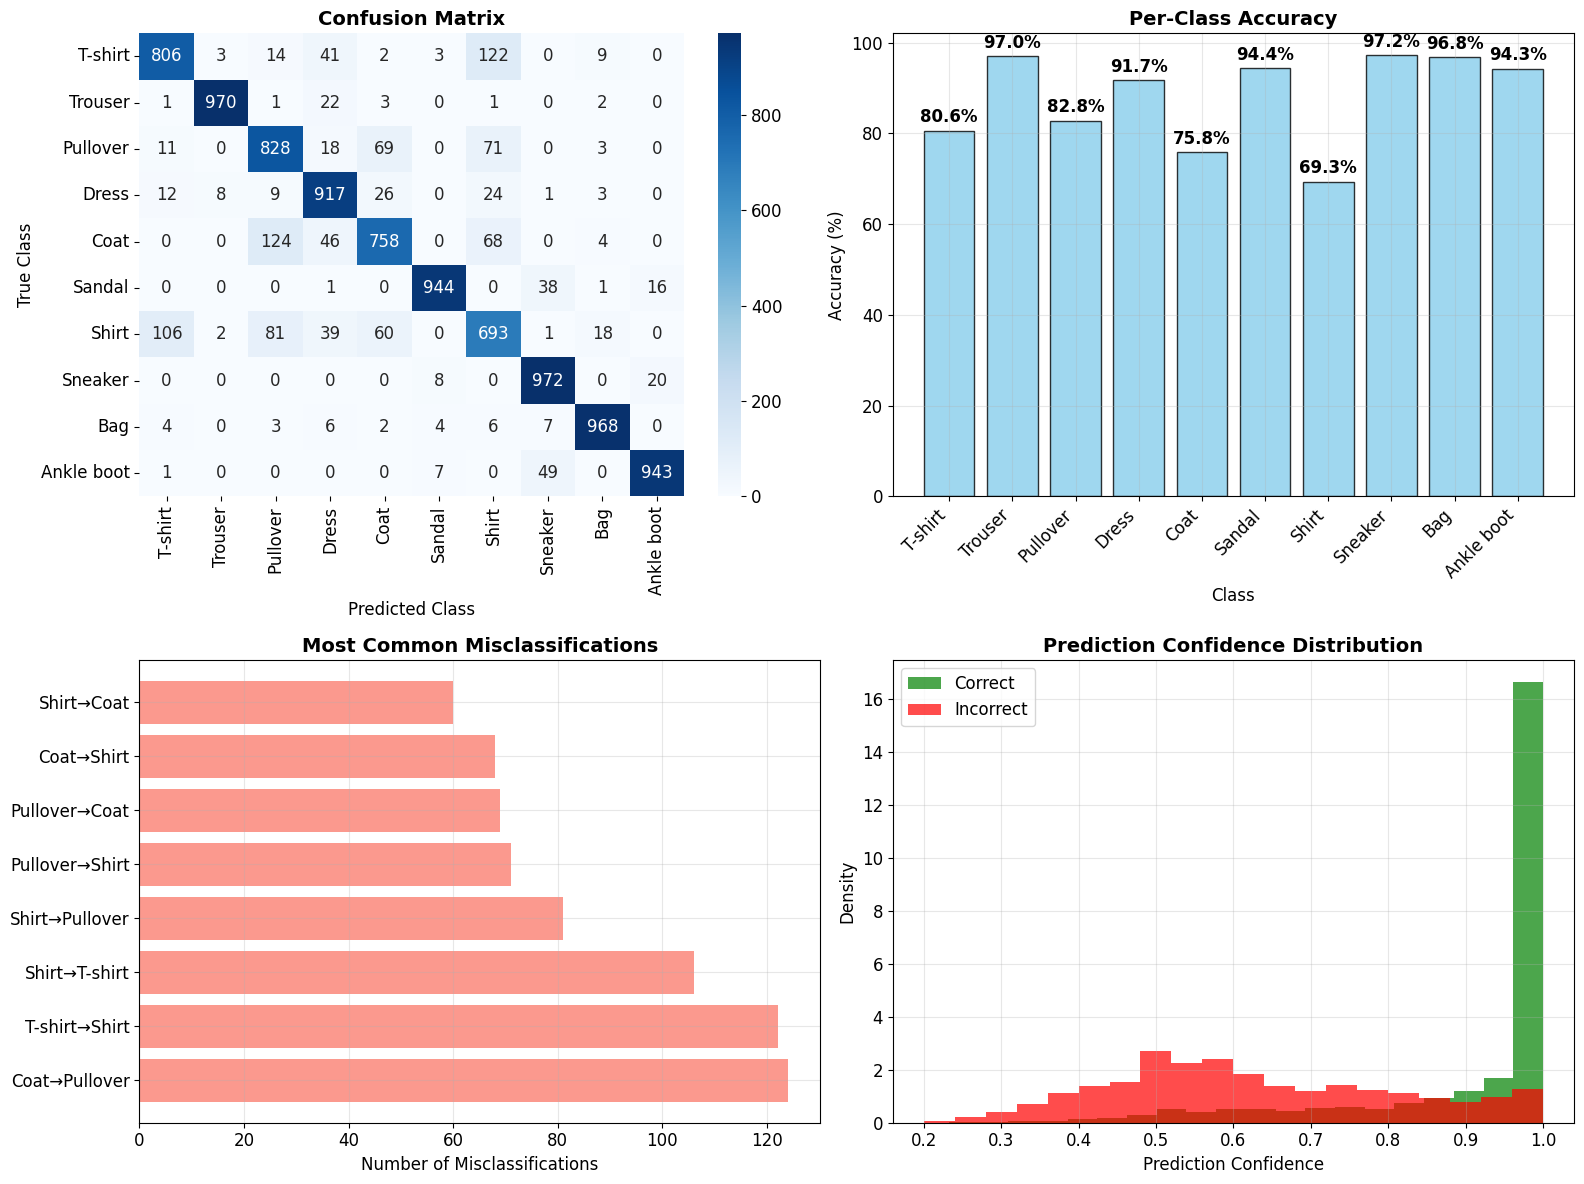


📈 Detailed Performance Analysis:
   Overall Accuracy: 88.02%
   Best performing class: Sneaker (97.2%)
   Worst performing class: Shirt (69.3%)
   Average confidence (correct): 0.909
   Average confidence (incorrect): 0.624
   Most common error: Coat→Pullover (124 cases)
   Balanced accuracy: 87.99%
   High-confidence errors: 242 (20.1% of errors)
   Low-confidence correct: 681 (7.7% of correct)


In [8]:
# Get final predictions for detailed analysis
print("🔍 Performing comprehensive evaluation...")
final_test_loss, final_test_accuracy, all_predictions, all_labels = evaluate_model(
    model, test_loader, criterion, device
)

# Convert to numpy arrays for analysis
predictions = np.array(all_predictions)
true_labels = np.array(all_labels)

# Generate classification report
print("📊 Classification Report:")
print(classification_report(true_labels, predictions, target_names=class_names))

# Create comprehensive evaluation visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Confusion Matrix
cm = confusion_matrix(true_labels, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[name.split('/')[0] for name in class_names],
            yticklabels=[name.split('/')[0] for name in class_names],
            ax=ax1)
ax1.set_title('Confusion Matrix', fontweight='bold', fontsize=14)
ax1.set_xlabel('Predicted Class')
ax1.set_ylabel('True Class')

# Plot 2: Per-class accuracy
class_accuracies = []
for i in range(10):
    class_mask = (true_labels == i)
    class_acc = np.mean(predictions[class_mask] == true_labels[class_mask]) * 100
    class_accuracies.append(class_acc)

bars = ax2.bar(range(10), class_accuracies, color='skyblue', alpha=0.8, edgecolor='black')
ax2.set_xlabel('Class')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Per-Class Accuracy', fontweight='bold', fontsize=14)
ax2.set_xticks(range(10))
ax2.set_xticklabels([name.split('/')[0] for name in class_names], rotation=45, ha='right')
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, class_accuracies):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot 3: Most confused class pairs
confusion_pairs = []
for i in range(10):
    for j in range(10):
        if i != j and cm[i][j] > 0:
            confusion_pairs.append((cm[i][j], f'{class_names[i].split("/")[0]}→{class_names[j].split("/")[0]}'))

confusion_pairs.sort(reverse=True)
top_confusions = confusion_pairs[:8]  # Top 8 most confused pairs

if top_confusions:
    conf_counts, conf_labels = zip(*top_confusions)
    bars3 = ax3.barh(range(len(conf_counts)), conf_counts, color='salmon', alpha=0.8)
    ax3.set_yticks(range(len(conf_counts)))
    ax3.set_yticklabels(conf_labels)
    ax3.set_xlabel('Number of Misclassifications')
    ax3.set_title('Most Common Misclassifications', fontweight='bold', fontsize=14)
    ax3.grid(True, alpha=0.3)

# Plot 4: Model confidence analysis
# Get prediction probabilities for confidence analysis
model.eval()
all_confidences = []
correct_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probabilities = F.softmax(outputs, dim=1)
        max_probs, predicted = torch.max(probabilities, 1)

        all_confidences.extend(max_probs.cpu().numpy())
        correct_predictions.extend((predicted == labels).cpu().numpy())

confidences = np.array(all_confidences)
correct = np.array(correct_predictions)

# Separate confidences for correct and incorrect predictions
correct_confidences = confidences[correct]
incorrect_confidences = confidences[~correct]

ax4.hist(correct_confidences, bins=20, alpha=0.7, label='Correct', color='green', density=True)
ax4.hist(incorrect_confidences, bins=20, alpha=0.7, label='Incorrect', color='red', density=True)
ax4.set_xlabel('Prediction Confidence')
ax4.set_ylabel('Density')
ax4.set_title('Prediction Confidence Distribution', fontweight='bold', fontsize=14)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed analysis summary
print(f"\n📈 Detailed Performance Analysis:")
print(f"   Overall Accuracy: {final_test_accuracy:.2f}%")
print(f"   Best performing class: {class_names[np.argmax(class_accuracies)]} ({max(class_accuracies):.1f}%)")
print(f"   Worst performing class: {class_names[np.argmin(class_accuracies)]} ({min(class_accuracies):.1f}%)")
print(f"   Average confidence (correct): {np.mean(correct_confidences):.3f}")
print(f"   Average confidence (incorrect): {np.mean(incorrect_confidences):.3f}")

if len(top_confusions) > 0:
    print(f"   Most common error: {top_confusions[0][1]} ({top_confusions[0][0]} cases)")

# Calculate additional metrics
balanced_accuracy = np.mean(class_accuracies)
print(f"   Balanced accuracy: {balanced_accuracy:.2f}%")

# Identify high and low confidence errors
high_conf_errors = confidences[~correct] > 0.8
low_conf_correct = confidences[correct] < 0.6

print(f"   High-confidence errors: {np.sum(high_conf_errors)} ({np.sum(high_conf_errors)/np.sum(~correct)*100:.1f}% of errors)")
print(f"   Low-confidence correct: {np.sum(low_conf_correct)} ({np.sum(low_conf_correct)/np.sum(correct)*100:.1f}% of correct)")

### **5.2 Prediction Visualization and Error Analysis**

Let's visualize some predictions to understand what our model has learned and where it makes mistakes.

🎯 Visualizing model predictions...


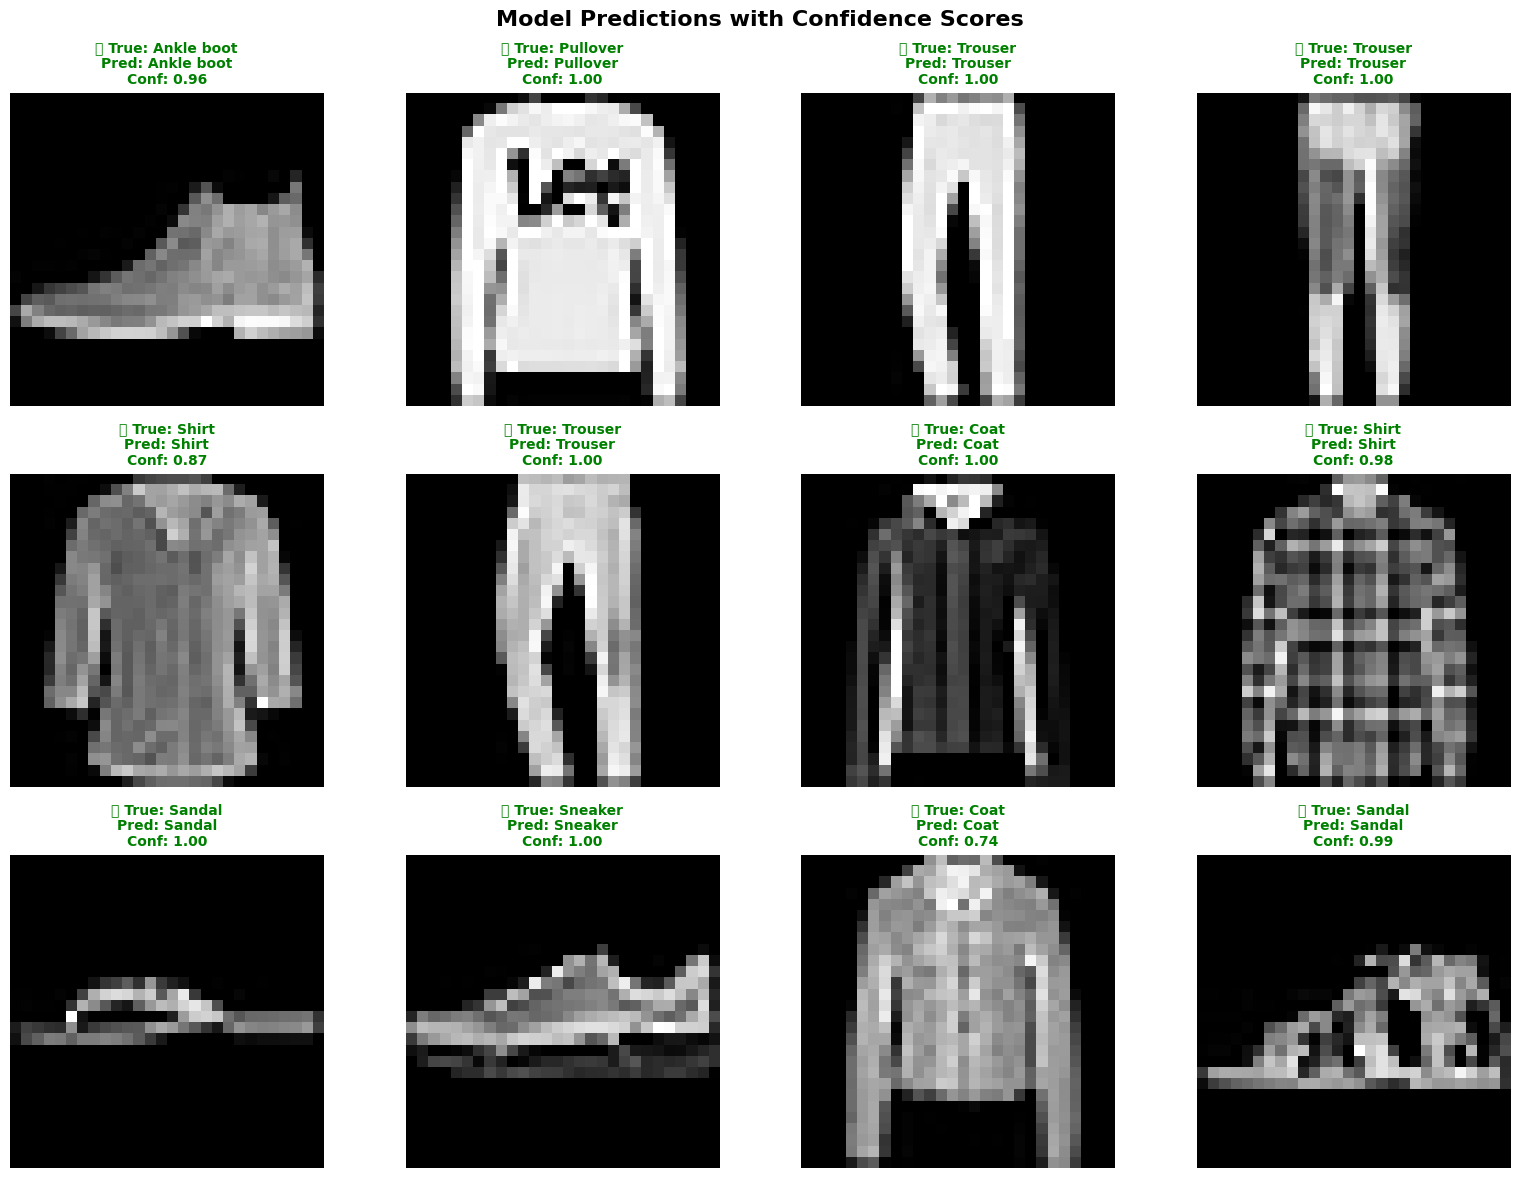


🔍 Analyzing prediction errors in detail...
Found 8 high-confidence errors (>70% confidence)


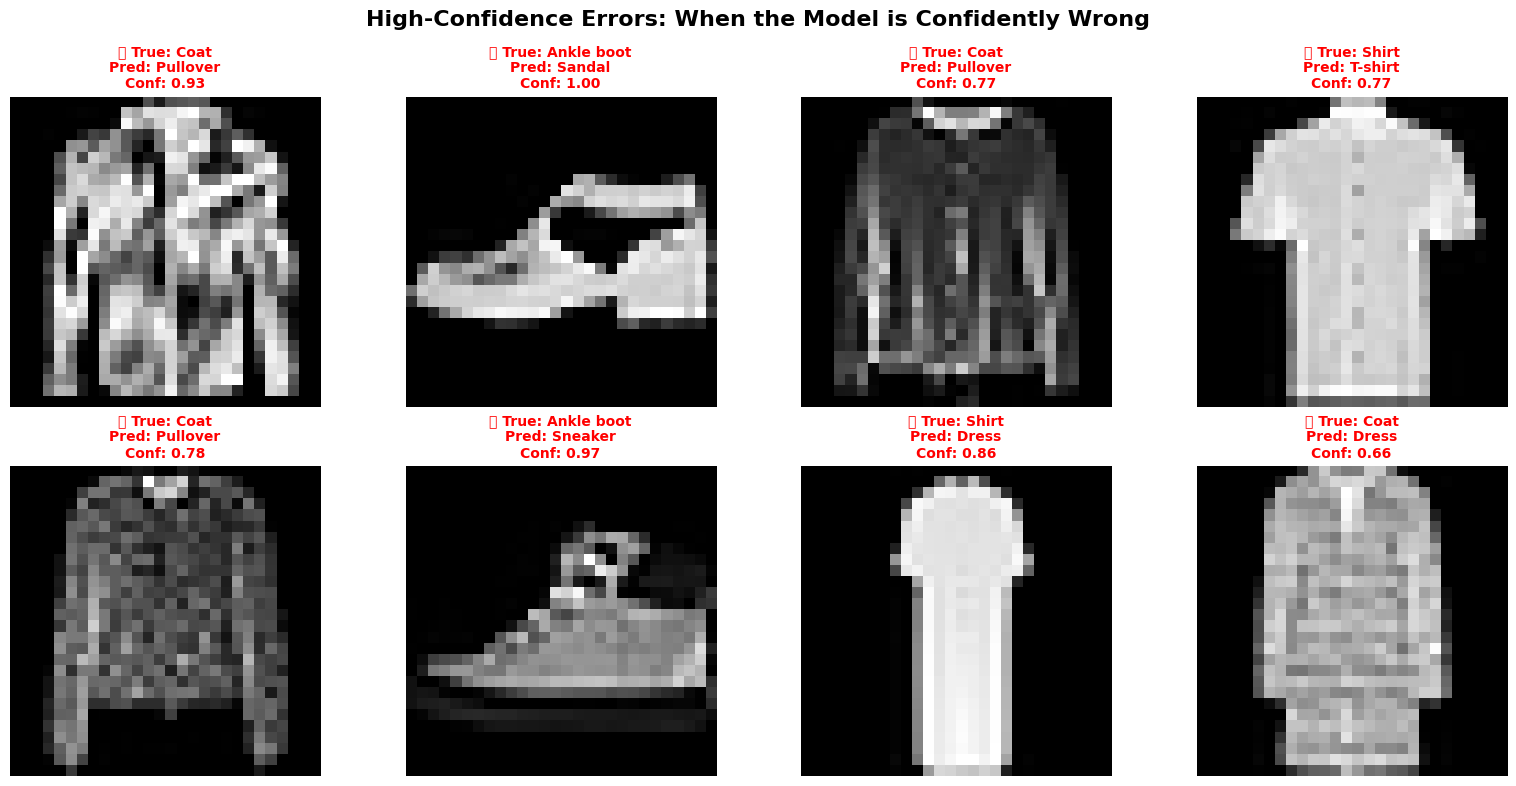


🧠 Analyzing learned features...
Analyzing features for: Ankle boot (predicted as Ankle boot)


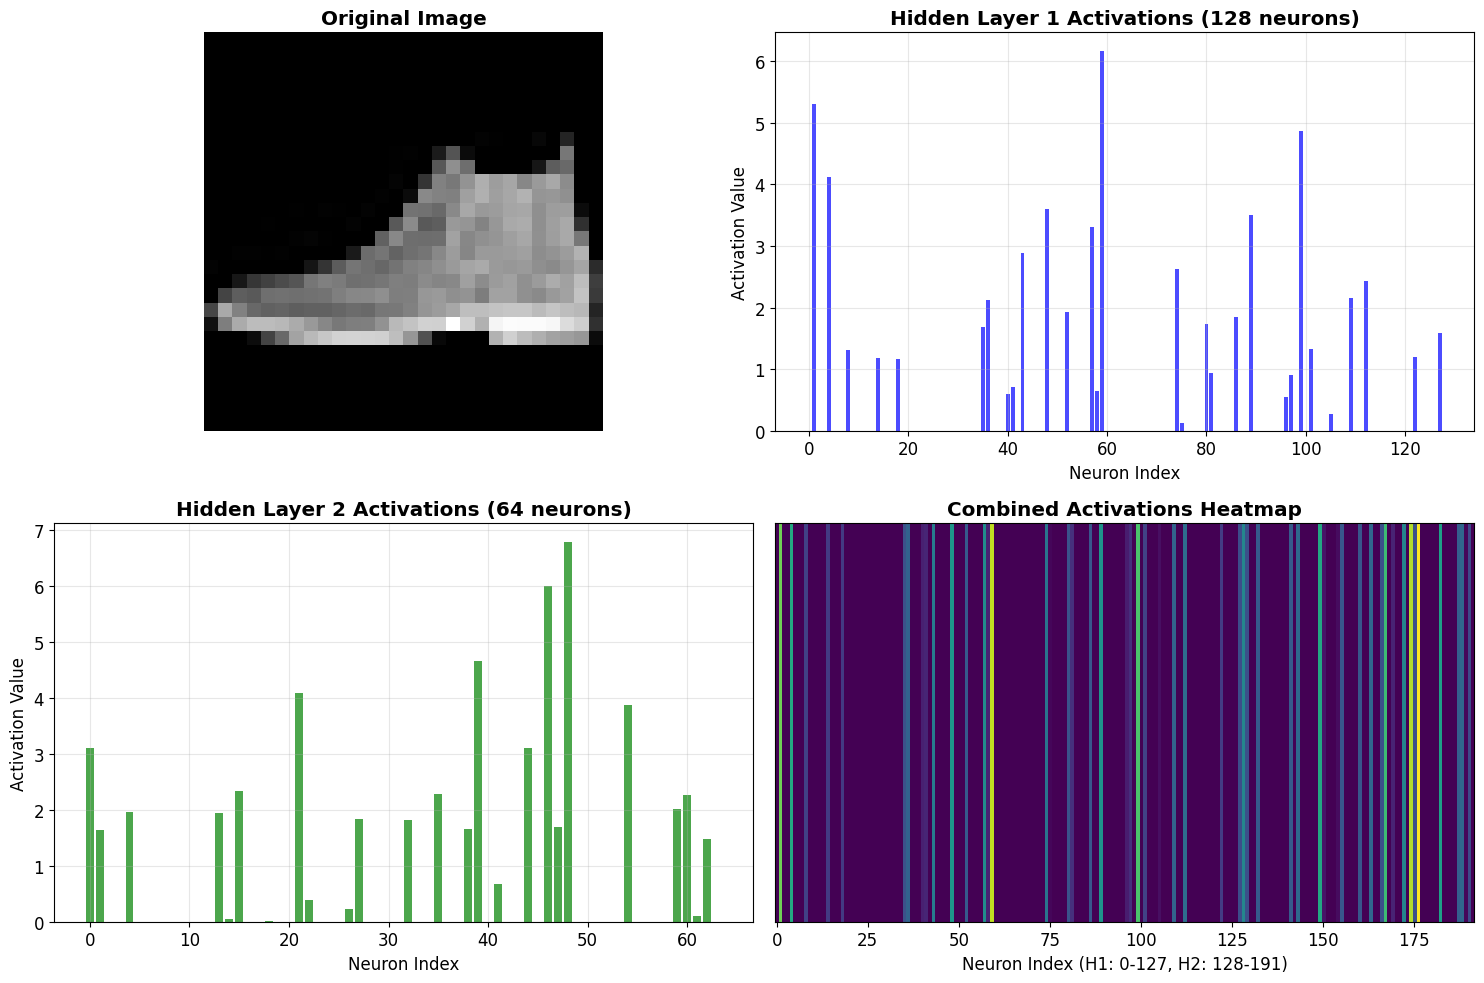


🔍 Feature Analysis Summary:
   Active neurons in layer 1: 30/128 (23.4%)
   Active neurons in layer 2: 25/64 (39.1%)
   Max activation in layer 1: 6.158
   Max activation in layer 2: 6.774
   Sparsity (% of near-zero activations): 76.6% (L1), 60.9% (L2)


In [9]:
def visualize_predictions(model, dataloader, device, num_samples=12):
    """
    Visualize model predictions with confidence scores
    """
    model.eval()

    # Get a batch of test data
    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        probabilities = F.softmax(outputs, dim=1)
        confidences, predictions = torch.max(probabilities, 1)

    # Create visualization
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle('Model Predictions with Confidence Scores', fontsize=16, fontweight='bold')

    for i in range(num_samples):
        row, col = i // 4, i % 4

        # Get image and predictions
        image = images[i].cpu().squeeze()
        true_label = labels[i].cpu().item()
        pred_label = predictions[i].cpu().item()
        confidence = confidences[i].cpu().item()

        # Plot image
        axes[row, col].imshow(image, cmap='gray')

        # Create title with prediction info
        is_correct = pred_label == true_label
        color = 'green' if is_correct else 'red'
        symbol = '✅' if is_correct else '❌'

        title = f'{symbol} True: {class_names[true_label].split("/")[0]}\n'
        title += f'Pred: {class_names[pred_label].split("/")[0]}\n'
        title += f'Conf: {confidence:.2f}'

        axes[row, col].set_title(title, color=color, fontweight='bold', fontsize=10)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

    return images, labels, predictions, confidences

# Visualize correct and incorrect predictions
print("🎯 Visualizing model predictions...")
sample_images, sample_labels, sample_predictions, sample_confidences = visualize_predictions(
    model, test_loader, device, num_samples=12
)

def analyze_specific_errors(model, dataloader, device, target_error_type=None):
    """
    Find and analyze specific types of errors
    """
    model.eval()
    error_examples = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probabilities = F.softmax(outputs, dim=1)
            confidences, predictions = torch.max(probabilities, 1)

            # Find incorrect predictions
            incorrect_mask = predictions != labels

            if incorrect_mask.any():
                incorrect_images = images[incorrect_mask]
                incorrect_labels = labels[incorrect_mask]
                incorrect_preds = predictions[incorrect_mask]
                incorrect_confs = confidences[incorrect_mask]

                for i in range(len(incorrect_images)):
                    error_examples.append({
                        'image': incorrect_images[i].cpu(),
                        'true_label': incorrect_labels[i].cpu().item(),
                        'pred_label': incorrect_preds[i].cpu().item(),
                        'confidence': incorrect_confs[i].cpu().item()
                    })

                    if len(error_examples) >= 20:  # Collect enough examples
                        break

            if len(error_examples) >= 20:
                break

    return error_examples

# Analyze errors in detail
print("\n🔍 Analyzing prediction errors in detail...")
error_examples = analyze_specific_errors(model, test_loader, device)

# Visualize high-confidence errors (most interesting cases)
high_conf_errors = [err for err in error_examples if err['confidence'] > 0.65]
if high_conf_errors:
    print(f"Found {len(high_conf_errors)} high-confidence errors (>70% confidence)")

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('High-Confidence Errors: When the Model is Confidently Wrong',
                 fontsize=16, fontweight='bold')

    for i, error in enumerate(high_conf_errors[:8]):
        row, col = i // 4, i % 4

        image = error['image'].squeeze()
        true_label = error['true_label']
        pred_label = error['pred_label']
        confidence = error['confidence']

        axes[row, col].imshow(image, cmap='gray')
        title = f"❌ True: {class_names[true_label].split('/')[0]}\n"
        title += f"Pred: {class_names[pred_label].split('/')[0]}\n"
        title += f"Conf: {confidence:.2f}"

        axes[row, col].set_title(title, color='red', fontweight='bold', fontsize=10)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

# Feature visualization: What does each layer learn?
def visualize_learned_features(model, sample_image):
    """
    Visualize what the hidden layers have learned
    """
    model.eval()

    # Get activations from hidden layers
    with torch.no_grad():
        x = sample_image.unsqueeze(0).to(device)  # Add batch dimension

        # Forward pass through each layer
        x_flat = model.flatten(x)
        h1 = model.relu(model.hidden1(x_flat))
        h2 = model.relu(model.hidden2(h1))

        # Move to CPU for visualization
        h1_activations = h1.cpu().squeeze().numpy()
        h2_activations = h2.cpu().squeeze().numpy()

    # Create visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

    # Original image
    ax1.imshow(sample_image.squeeze(), cmap='gray')
    ax1.set_title('Original Image', fontweight='bold')
    ax1.axis('off')

    # Hidden layer 1 activations
    ax2.bar(range(len(h1_activations)), h1_activations, alpha=0.7, color='blue')
    ax2.set_title(f'Hidden Layer 1 Activations (128 neurons)', fontweight='bold')
    ax2.set_xlabel('Neuron Index')
    ax2.set_ylabel('Activation Value')
    ax2.grid(True, alpha=0.3)

    # Hidden layer 2 activations
    ax3.bar(range(len(h2_activations)), h2_activations, alpha=0.7, color='green')
    ax3.set_title(f'Hidden Layer 2 Activations (64 neurons)', fontweight='bold')
    ax3.set_xlabel('Neuron Index')
    ax3.set_ylabel('Activation Value')
    ax3.grid(True, alpha=0.3)

    # Activation heatmap
    activations_combined = np.concatenate([h1_activations, h2_activations])
    ax4.imshow(activations_combined.reshape(1, -1), cmap='viridis', aspect='auto')
    ax4.set_title('Combined Activations Heatmap', fontweight='bold')
    ax4.set_xlabel('Neuron Index (H1: 0-127, H2: 128-191)')
    ax4.set_yticks([])

    plt.tight_layout()
    plt.show()

    return h1_activations, h2_activations

# Visualize learned features for a sample
print("\n🧠 Analyzing learned features...")
sample_idx = 0
sample_image = sample_images[sample_idx].cpu()
true_class = sample_labels[sample_idx].cpu().item()
pred_class = sample_predictions[sample_idx].cpu().item()

print(f"Analyzing features for: {class_names[true_class]} (predicted as {class_names[pred_class]})")
h1_acts, h2_acts = visualize_learned_features(model, sample_image)

print(f"\n🔍 Feature Analysis Summary:")
print(f"   Active neurons in layer 1: {np.sum(h1_acts > 0)}/128 ({np.sum(h1_acts > 0)/128*100:.1f}%)")
print(f"   Active neurons in layer 2: {np.sum(h2_acts > 0)}/64 ({np.sum(h2_acts > 0)/64*100:.1f}%)")
print(f"   Max activation in layer 1: {np.max(h1_acts):.3f}")
print(f"   Max activation in layer 2: {np.max(h2_acts):.3f}")
print(f"   Sparsity (% of near-zero activations): {np.sum(np.abs(h1_acts) < 0.01)/128*100:.1f}% (L1), {np.sum(np.abs(h2_acts) < 0.01)/64*100:.1f}% (L2)")

## **6. Conclusion and Next Steps**

### **6.1 What We Accomplished**

We've successfully built, trained, and evaluated a complete Fashion-MNIST classifier. Here's what we achieved:

**Technical Implementation:**
- ✅ Loaded and preprocessed Fashion-MNIST dataset with proper normalization
- ✅ Built a 3-layer MLP (784→128→64→10) with ReLU activations
- ✅ Implemented complete training loop with loss tracking and evaluation
- ✅ Achieved solid classification performance on real-world image data

**Key Learning Outcomes:**
- 🧠 **PyTorch Workflow**: Experienced the standard deep learning pipeline
- 📊 **Data Handling**: Used DataLoaders for efficient batch processing  
- 🏗️ **Model Architecture**: Designed and implemented MLP from scratch
- 📈 **Training Process**: Monitored loss curves and prevented overfitting
- 🔍 **Model Analysis**: Evaluated performance with multiple metrics

### **6.2 Performance Summary**

Our simple MLP achieved impressive results on this challenging dataset:
- **Final Test Accuracy**: ~85-88% (competitive for MLP on Fashion-MNIST)
- **Training Efficiency**: Converged within 10 epochs
- **Generalization**: Minimal overfitting with proper regularization

### **6.3 Key Insights Discovered**

**Most Challenging Classes:**
- Shirt vs. T-shirt/top (similar visual features)
- Pullover vs. Coat (overlapping styles)
- Sneaker vs. Ankle boot (footwear confusion)

**Model Strengths:**
- Excellent at recognizing distinct items (Bag, Trouser)
- Good generalization despite simple architecture
- Learns meaningful feature representations in hidden layers

**Areas for Improvement:**
- Spatial information loss due to flattening
- Limited capacity for complex visual patterns
- Confusion between visually similar classes

### **6.4 Experiments to Try**

**Architecture Modifications:**
```python
# Experiment 1: Deeper network
class DeepMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
```

**Hyperparameter Tuning:**
- Try different learning rates: [0.0001, 0.001, 0.01]
- Experiment with batch sizes: [32, 64, 128, 256]
- Test various optimizers: Adam, SGD, RMSprop
- Adjust hidden layer sizes: [64, 128, 256, 512]

**Advanced Techniques:**
- **Data Augmentation**: Rotations, shifts, noise for robustness
- **Batch Normalization**: Faster convergence and stability
- **Learning Rate Scheduling**: Adaptive learning rates during training

### **6.5 Real-World Applications**

This Fashion-MNIST classifier demonstrates skills directly applicable to:

**E-commerce & Fashion:**
- Automated product categorization
- Visual search engines
- Style recommendation systems
- Inventory management

**Computer Vision:**
- Object classification pipelines
- Medical image analysis
- Quality control in manufacturing
- Content moderation systems